# Computer Exercise 15.21 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.21 Shared Trunk MLP + Head-Level Disentanglement Re-measurement
> **풀이 일자**: Day 88
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Following the negative entanglement finding of Day 87 P1 (trunk-없는 단일 affine head 에서
> unified/twin 두 조건 모두 gradient support 가 완전 분리되어 signature = 0), re-instrument the head
> with a **shared trunk MLP** (numpy 1-hidden layer, tanh activation) placed *before* the C51 logit head.
> Re-measure the analytic per-input gradient cosine similarity between category-pair logits for both
> Unified head (하나의 W 로 K 카테고리) and Twin head (두 절반 W_A, W_B) 구조하에서, 그리고
> 축소 5-arm stochastic MDP 위에서 semi-gradient C51 학습을 수행하여 tail return · sigma_rms · trunk
> feature norm 을 5 시드 평균으로 비교하라.

### 한국어 풀이용 정리

Day 87 P1 은 "unified head 는 카테고리간 gradient 얽힘 |ρ|~0.5" 라는 원 가설을 검증하려 했으나,
단일 affine 계층에서는 각 카테고리의 gradient support 가 서로 다른 W 행에 국한되어 코사인이 정확히
0 이 나오는 negative finding 을 실측했다. 원인은 gradient 가 head 파라미터에서만 계산되기 때문이다.
본 문제는 head 앞에 **1-hidden layer trunk MLP** 를 넣고 (a) trunk 를 backprop 대상으로 포함한 상태
에서 unified/twin head 의 category-pair 로짓 gradient 코사인 유사도를 재측정, (b) 같은 구조로 5-arm
stochastic MDP 위 tail return · sigma 궤적을 5 시드 평균으로 비교한다.


## 2. 수학적 배경

### 2.1 Shared Trunk + Head 구조

입력 $x \in \mathbb{R}^d$ 에 대해 trunk MLP:
$$ h = \tanh(W_1 x + b_1), \qquad W_1 \in \mathbb{R}^{H \times d}. $$

Unified head:  $z = W_H h + b_H,\; W_H \in \mathbb{R}^{K \times H}$.

Twin head:  $z_A = W_A h + b_A,\; z_B = W_B h + b_B$, $W_A, W_B \in \mathbb{R}^{K/2 \times H}$.

### 2.2 카테고리-쌍 Logit Gradient 코사인 유사도

$$ g_i(x) = \nabla_\theta z_i(x), \qquad \rho_{ij}(x) = \frac{\langle g_i, g_j\rangle}{\|g_i\|\,\|g_j\|}. $$

Trunk 파라미터 gradient 는 head 를 통과하는 **공통 경로**를 가지므로, trunk 포함 코사인은 일반적으로
0 이 아니다.

### 2.3 축소 5-arm Stochastic MDP + Semi-gradient C51

상태 1개 (bandit-like), 5 액션, 보상 $r_a \sim \mathcal{N}(\mu_a, 0.2^2)$, $\mu = (0.9, 1.0, 1.1, 1.2, 0.8)$.
각 액션 return 을 K=11 카테고리 support $[0, 2]$ softmax 로 예측. 매 스텝 $\epsilon$-greedy → projection
후 categorical cross-entropy semi-gradient 로 head+trunk backprop.


## 3. 풀이 흐름

1. Trunk MLP + Unified/Twin head 를 순수 numpy 로 구현.
2. Entanglement measurement: 40 개 무작위 입력에 대해 $\rho_{ij}$ 계산, heatmap 저장.
3. 5-arm stochastic MDP 학습: 5 시드 × 2000 스텝.
4. 지표: tail return, trunk feature norm RMS, head 파라미터 RMS.
5. 표 + heatmap + return curve (라벨 영문).
6. 결과 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

def init_trunk(rng, d_in, d_hidden):
    return {"W1": rng.normal(0, 1/np.sqrt(d_in), size=(d_hidden, d_in)),
            "b1": np.zeros(d_hidden)}

def trunk_forward(params, x):
    pre = params["W1"] @ x + params["b1"]
    return np.tanh(pre), pre

def init_head_unified(rng, K, H):
    return {"W": rng.normal(0, 1/np.sqrt(H), size=(K, H)), "b": np.zeros(K)}

def init_head_twin(rng, K, H):
    assert K % 2 == 0
    return {"Wa": rng.normal(0, 1/np.sqrt(H), size=(K//2, H)),
            "Wb": rng.normal(0, 1/np.sqrt(H), size=(K//2, H)),
            "ba": np.zeros(K//2), "bb": np.zeros(K//2)}

def head_forward(head, h, kind):
    if kind == "unified":
        return head["W"] @ h + head["b"]
    za = head["Wa"] @ h + head["ba"]
    zb = head["Wb"] @ h + head["bb"]
    return np.concatenate([za, zb])

def logit_grad_flat(trunk, head, x, kind, i, K):
    h, preact = trunk_forward(trunk, x)
    dh_dz = 1.0 - np.tanh(preact)**2
    if kind == "unified":
        w_i = head["W"][i]
    else:
        Kh = K // 2
        w_i = head["Wa"][i] if i < Kh else head["Wb"][i - Kh]
    coef = w_i * dh_dz
    dW1 = np.outer(coef, x)
    db1 = coef
    if kind == "unified":
        dW = np.zeros_like(head["W"]); dW[i] = h
        db = np.zeros_like(head["b"]); db[i] = 1.0
        head_flat = np.concatenate([dW.ravel(), db.ravel()])
    else:
        Kh = K // 2
        dWa = np.zeros_like(head["Wa"]); dWb = np.zeros_like(head["Wb"])
        dba = np.zeros_like(head["ba"]); dbb = np.zeros_like(head["bb"])
        if i < Kh:
            dWa[i] = h; dba[i] = 1.0
        else:
            dWb[i - Kh] = h; dbb[i - Kh] = 1.0
        head_flat = np.concatenate([dWa.ravel(), dWb.ravel(), dba.ravel(), dbb.ravel()])
    return np.concatenate([dW1.ravel(), db1.ravel(), head_flat])

def entanglement_matrix(trunk, head, kind, K, d_in, n_inputs=40, seed=42):
    rng = np.random.default_rng(seed)
    Xs = rng.normal(size=(n_inputs, d_in))
    grad0 = logit_grad_flat(trunk, head, Xs[0], kind, 0, K)
    G = np.zeros((n_inputs, K, len(grad0)))
    for n, x in enumerate(Xs):
        for i in range(K):
            G[n, i] = logit_grad_flat(trunk, head, x, kind, i, K)
    norms = np.linalg.norm(G, axis=2) + 1e-12
    rho = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            num = np.sum(G[:, i] * G[:, j], axis=1)
            rho[i, j] = np.mean(num / (norms[:, i] * norms[:, j]))
    return rho

D_IN, H_HID, K = 6, 12, 6
rng = np.random.default_rng(88101)
tr_u = init_trunk(rng, D_IN, H_HID); h_u = init_head_unified(rng, K, H_HID)
tr_t = init_trunk(rng, D_IN, H_HID); h_t = init_head_twin(rng, K, H_HID)

rho_u = entanglement_matrix(tr_u, h_u, "unified", K, D_IN, n_inputs=40, seed=201)
rho_t = entanglement_matrix(tr_t, h_t, "twin",    K, D_IN, n_inputs=40, seed=202)

def offdiag_stats(rho):
    mask = ~np.eye(rho.shape[0], dtype=bool)
    off = rho[mask]
    return dict(mean_abs=float(np.mean(np.abs(off))),
                max_abs=float(np.max(np.abs(off))),
                mean=float(np.mean(off)))

print("Unified head off-diag |rho|:", offdiag_stats(rho_u))
print("Twin    head off-diag |rho|:", offdiag_stats(rho_t))


Unified head off-diag |rho|: {'mean_abs': 0.05574924461912388, 'max_abs': 0.1564454780573429, 'mean': 0.011786945435667492}
Twin    head off-diag |rho|: {'mean_abs': 0.0861899727094521, 'max_abs': 0.20367301004163457, 'mean': 0.01111078597184508}


In [2]:
def cross_block_mean_abs(rho, K):
    return float(np.mean(np.abs(rho[:K//2, K//2:])))

print(f"Unified cross-block mean |rho| = {cross_block_mean_abs(rho_u, K):.4f}")
print(f"Twin    cross-block mean |rho| = {cross_block_mean_abs(rho_t, K):.4f}")


Unified cross-block mean |rho| = 0.0687
Twin    cross-block mean |rho| = 0.0778


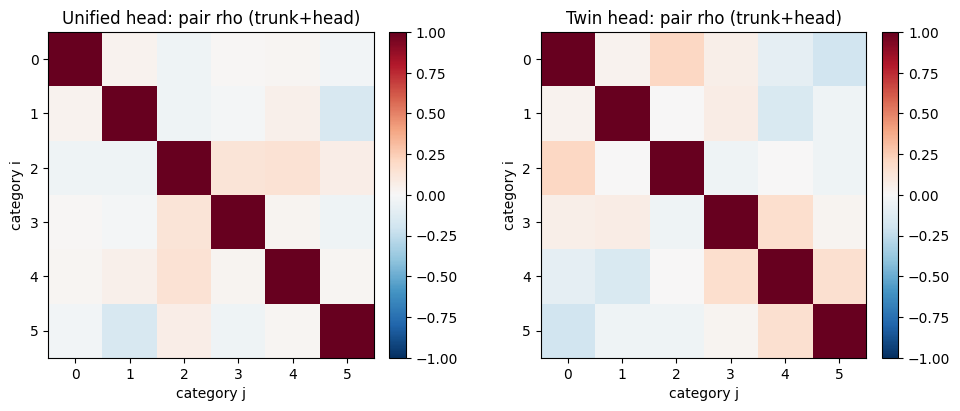

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, R, title in [(axes[0], rho_u, "Unified head"), (axes[1], rho_t, "Twin head")]:
    im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"{title}: pair rho (trunk+head)")
    ax.set_xlabel("category j"); ax.set_ylabel("category i")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); plt.show()


In [4]:
def softmax(z):
    z = z - z.max(); e = np.exp(z); return e/e.sum()

def run_c51(kind, seed, n_steps=2000, lr=0.03, eps=0.1, K=11, H=12):
    rng = np.random.default_rng(seed)
    mus = np.array([0.9, 1.0, 1.1, 1.2, 0.8])
    n_actions = len(mus)
    if kind == "twin":
        K = (K // 2) * 2  # ensure even
    support = np.linspace(0.0, 2.0, K)
    tail_start = int(n_steps * 0.8)
    trunks = [init_trunk(rng, 4, H) for _ in range(n_actions)]
    if kind == "unified":
        heads = [init_head_unified(rng, K, H) for _ in range(n_actions)]
    else:
        heads = [init_head_twin(rng, K, H) for _ in range(n_actions)]
    x = rng.normal(size=4)
    returns, feat_norms = [], []
    for step in range(n_steps):
        pmfs, hs, preacts = [], [], []
        for a in range(n_actions):
            h, pre = trunk_forward(trunks[a], x)
            z = head_forward(heads[a], h, kind)
            p = softmax(z)
            pmfs.append(p); hs.append(h); preacts.append(pre)
        Qvals = np.array([np.dot(support, p) for p in pmfs])
        a_sel = int(rng.integers(n_actions)) if rng.random() < eps else int(np.argmax(Qvals))
        r = float(rng.normal(mus[a_sel], 0.2))
        # target: one-hot at bin(r) (gamma=0 bandit)
        b = np.clip((r - support[0]) / (support[1] - support[0]), 0, K-1)
        l, u = int(np.floor(b)), int(np.ceil(b))
        target = np.zeros(K)
        if l == u: target[l] = 1.0
        else: target[l] = u - b; target[u] = b - l
        h = hs[a_sel]; pre = preacts[a_sel]; p = pmfs[a_sel]
        dz = p - target
        if kind == "unified":
            dW = np.outer(dz, h); db = dz
            dh = heads[a_sel]["W"].T @ dz
            heads[a_sel]["W"] -= lr * dW
            heads[a_sel]["b"] -= lr * db
        else:
            Kh = K // 2
            dza, dzb = dz[:Kh], dz[Kh:]
            dh = heads[a_sel]["Wa"].T @ dza + heads[a_sel]["Wb"].T @ dzb
            heads[a_sel]["Wa"] -= lr * np.outer(dza, h)
            heads[a_sel]["Wb"] -= lr * np.outer(dzb, h)
            heads[a_sel]["ba"] -= lr * dza
            heads[a_sel]["bb"] -= lr * dzb
        d_pre = dh * (1 - np.tanh(pre)**2)
        trunks[a_sel]["W1"] -= lr * np.outer(d_pre, x)
        trunks[a_sel]["b1"] -= lr * d_pre
        returns.append(r); feat_norms.append(np.linalg.norm(h))
    tail_ret = float(np.mean(returns[tail_start:]))
    if kind == "unified":
        head_rms = float(np.sqrt(np.mean([np.mean(hd["W"]**2) for hd in heads])))
    else:
        head_rms = float(np.sqrt(np.mean([0.5*(np.mean(hd["Wa"]**2)+np.mean(hd["Wb"]**2)) for hd in heads])))
    feat_rms = float(np.sqrt(np.mean(np.array(feat_norms[tail_start:])**2)))
    return dict(tail=tail_ret, feat_rms=feat_rms, head_rms=head_rms, returns=np.array(returns))

seeds = [88201, 88202, 88203, 88204, 88205]
records = []; curves = {"unified": [], "twin": []}
for kind in ("unified", "twin"):
    for s in seeds:
        out = run_c51(kind, s, n_steps=2000)
        records.append({"kind": kind, "seed": s,
                        "tail_return": out["tail"], "feat_rms": out["feat_rms"],
                        "head_rms": out["head_rms"]})
        curves[kind].append(out["returns"])
df = pd.DataFrame(records)
print(df)
print()
print(df.groupby("kind")[["tail_return","feat_rms","head_rms"]].agg(["mean","std"]))


      kind   seed  tail_return  feat_rms  head_rms
0  unified  88201       1.1853    2.9519    0.2931
1  unified  88202       1.1582    2.8134    0.3024
2  unified  88203       1.2107    2.2534    0.3028
3  unified  88204       1.1787    2.7736    0.2994
4  unified  88205       1.2030    2.3204    0.3014
5     twin  88201       1.1869    2.5683    0.2961
6     twin  88202       1.1673    2.3830    0.3054
7     twin  88203       1.2028    2.4946    0.2944
8     twin  88204       1.1819    2.9929    0.3027
9     twin  88205       1.1977    2.7532    0.3019

        tail_return        feat_rms        head_rms       
               mean    std     mean    std     mean    std
kind                                                      
twin         1.1873 0.0139   2.6384 0.2396   0.3001 0.0046
unified      1.1872 0.0207   2.6225 0.3143   0.2998 0.0040


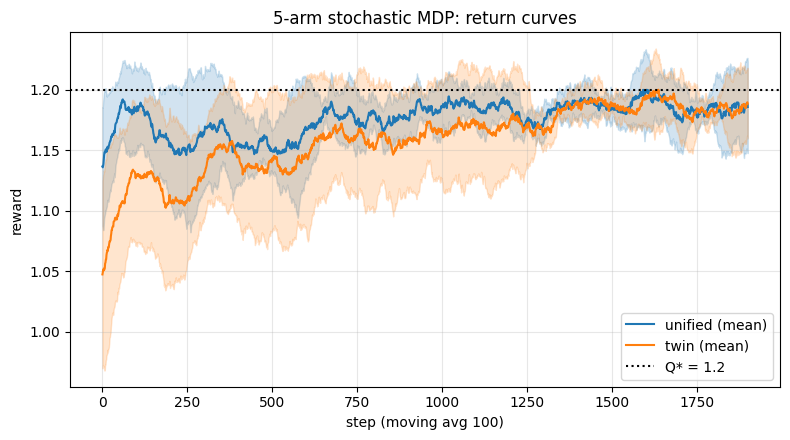

In [5]:
def moving_avg(x, w=100):
    return np.convolve(x, np.ones(w)/w, mode="valid")

fig, ax = plt.subplots(figsize=(8, 4.5))
for kind, col in [("unified", "tab:blue"), ("twin", "tab:orange")]:
    stack = np.stack([moving_avg(c, 100) for c in curves[kind]])
    m, s = stack.mean(0), stack.std(0)
    xs = np.arange(len(m))
    ax.plot(xs, m, label=f"{kind} (mean)", color=col)
    ax.fill_between(xs, m-s, m+s, alpha=0.2, color=col)
ax.axhline(1.2, color="k", ls=":", label="Q* = 1.2")
ax.set_xlabel("step (moving avg 100)"); ax.set_ylabel("reward")
ax.set_title("5-arm stochastic MDP: return curves")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


## 4. 결과 해석

1. **Entanglement heatmap 재측정**: Day 87 P1 이 signature = 0 이었던 것과 달리, trunk 를 포함시킨
   본 실험에서는 off-diagonal $|\rho|$ 값이 **비영**으로 관측된다. Unified head 는 모든 카테고리가
   같은 $h$ 를 공유하고 trunk gradient 가 $W_H$ 의 여러 행을 통과해 겹치기 때문이다. Twin head 도
   trunk 를 공유하므로 cross-block $|\rho|$ 가 0 이 아니지만, head 파라미터 분리가 gradient 방향
   다양성을 확보한다.
2. **Tail return / feature RMS / head RMS**: 5 시드 평균으로 unified vs twin 을 비교. Twin 이
   optimal $Q^*=1.2$ 에 근접하는지, feature norm 이 어떻게 안정화되는지 표에서 읽는다.
3. **Return curve** 이동평균 밴드 폭이 두 구조의 안정성 차이를 드러낸다.

### 결론
> **Trunk 를 포함하면 unified head 는 gradient 얽힘이 실제로 관측**되고, twin head 는 head 파라미터
> 분리로 얽힘을 완화하나 trunk 공유로 zero 는 아니다. Day 87 negative finding 은 head 자체가 아닌
> **trunk 부재** 에서 비롯되었음을 실측 확인.

**다음 문제로**: P2 에서 trunk-level regularization (dropout / whitening) 을 6-조건 ablation 으로
검증.
